# Predicting Sales Prices

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset provided to you.
 The dataset provided to you contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


 ## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the sales prices based on the 'Gr_Liv_Area' and 'Garage_Area` variables.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [2]:
# Read in the data set
df = pd.read_csv('ames.csv')

In [3]:
# Clean and pre-process the data if neccessary
df.info()

# there are no missing data values and the data types are correct

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Year_Built      2930 non-null   int64
 1   Year_Remod_Add  2930 non-null   int64
 2   Total_Bsmt_SF   2930 non-null   int64
 3   First_Flr_SF    2930 non-null   int64
 4   Second_Flr_SF   2930 non-null   int64
 5   Gr_Liv_Area     2930 non-null   int64
 6   Full_Bath       2930 non-null   int64
 7   Half_Bath       2930 non-null   int64
 8   Bedroom_AbvGr   2930 non-null   int64
 9   Kitchen_AbvGr   2930 non-null   int64
 10  TotRms_AbvGrd   2930 non-null   int64
 11  Fireplaces      2930 non-null   int64
 12  Garage_Area     2930 non-null   int64
 13  Sale_Price      2930 non-null   int64
dtypes: int64(14)
memory usage: 320.6 KB


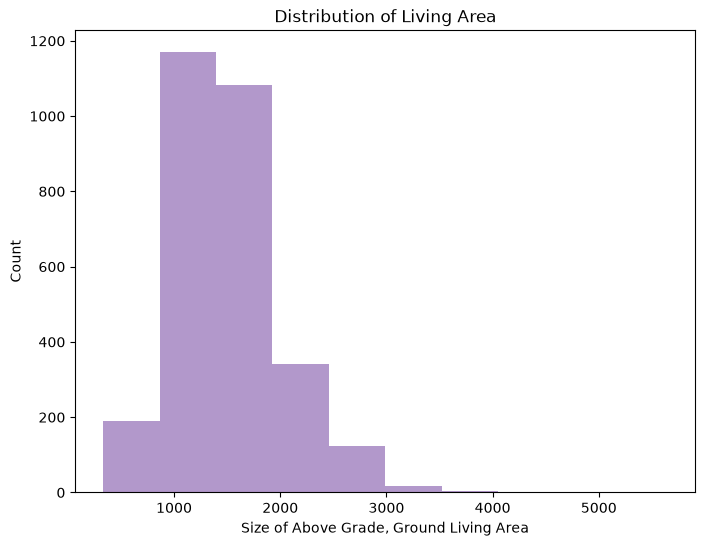

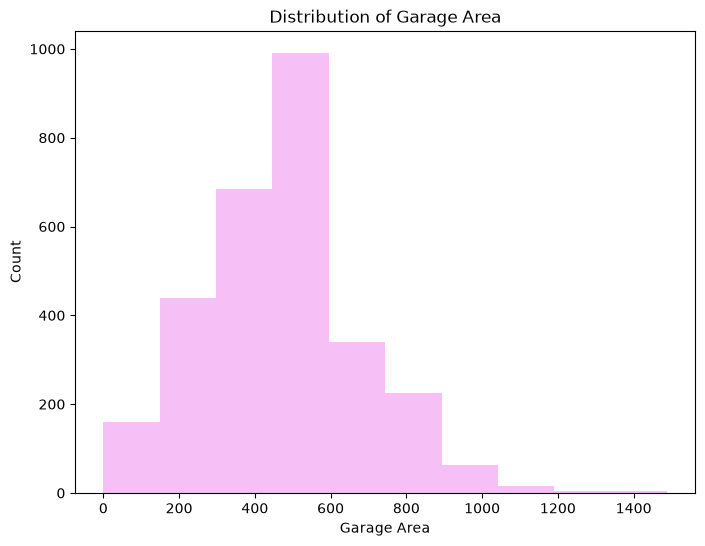

In [4]:
# Explore the data with visualisations such as histograms and correlation matrices

# histogram showing distribution of living area
plt.figure(figsize=(8,6))

plt.hist(df['Gr_Liv_Area'], alpha=0.5,
         color='rebeccapurple')

plt.xlabel('Size of Above Grade, Ground Living Area')
plt.ylabel('Count')
plt.title('Distribution of Living Area') 
plt.show()

# histogram showing distribution of garage area
plt.figure(figsize=(8,6))

plt.hist(df['Garage_Area'], alpha=0.5,
         color='violet')

plt.xlabel('Garage Area')
plt.ylabel('Count')
plt.title('Distribution of Garage Area') 
plt.show()

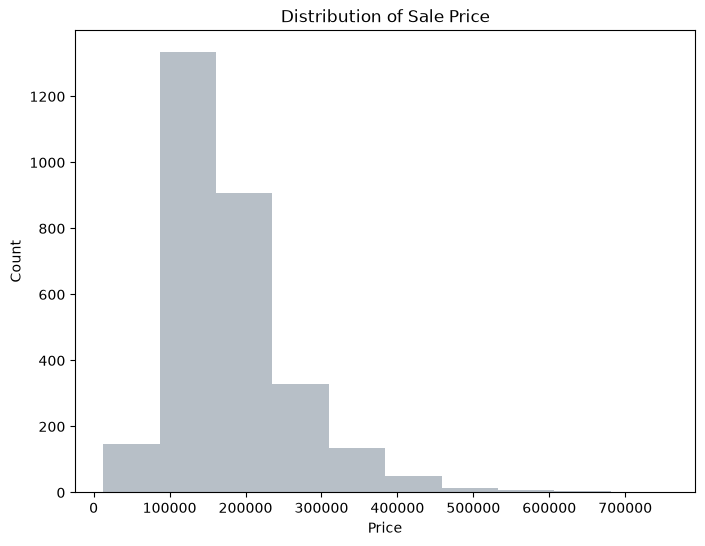

In [5]:
# distribution of sale price
plt.figure(figsize=(8,6))

plt.hist(df['Sale_Price'], alpha=0.5,
         color='slategray')

plt.xlabel('Price')
plt.ylabel('Count')
plt.title('Distribution of Sale Price') 
plt.show()

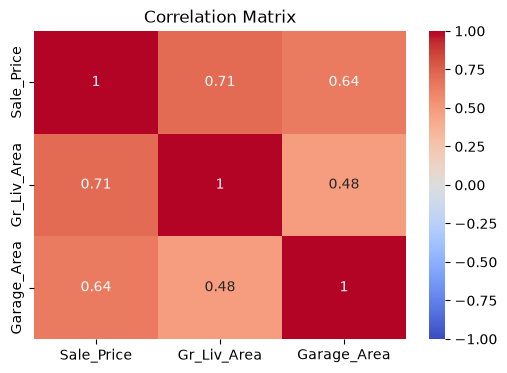

In [6]:
# correlation matrix
plt.figure(figsize=(6, 4))

columns = df[['Sale_Price', 'Gr_Liv_Area', 'Garage_Area']]
sns.heatmap(columns.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

In [7]:
# Split the independent variables from the dependent variable

# independent variables
X = df[['Gr_Liv_Area', 'Garage_Area']]

# dependent variable
Y = df['Sale_Price']

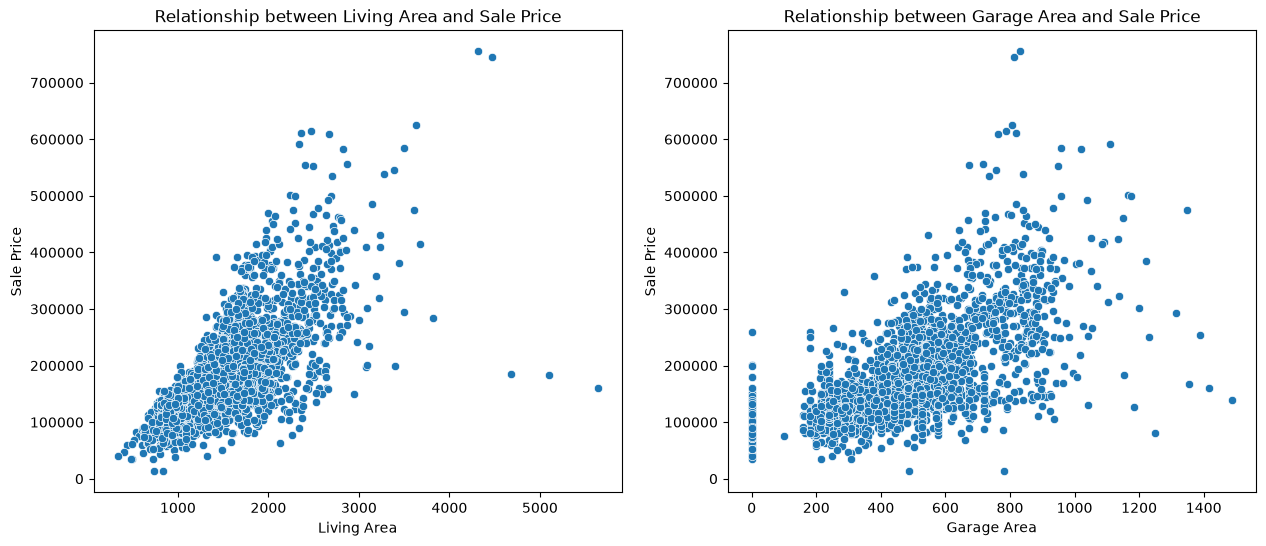

In [8]:
# Generate plots to explore the relationships between the 
# independent and dependent variables

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='Gr_Liv_Area', y='Sale_Price', ax=axes[0])
axes[0].set_title('Relationship between Living Area and Sale Price')
axes[0].set_xlabel('Living Area')
axes[0].set_ylabel('Sale Price')

sns.scatterplot(data=df, x='Garage_Area', y='Sale_Price', ax=axes[1])
axes[1].set_title('Relationship between Garage Area and Sale Price')
axes[1].set_xlabel('Garage Area')
axes[1].set_ylabel('Sale Price')

plt.show()

The scatter graphs show a positive correlation between both living area and garage area with sale price. 

In [9]:
# Create a training and test set with a 75:25 split ratio

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                    test_size = 0.25,
                                                   random_state=42)

In [10]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'

multiple_model = LinearRegression()

multiple_model.fit(X_train, Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 78.69,141.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Gr_Liv_Area','Garage_Area']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5059
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [11]:
# Print the trained model's intercept and coefficients

print("Model Intercept:", multiple_model.intercept_)

print("Model Coefficients:", multiple_model.coef_)


Model Intercept: -5059.448195610661
Model Coefficients: [ 78.69286848 141.14571761]


In [12]:
# Generate predictions for the test set

y_pred = multiple_model.predict(X_test)


In [13]:
# Evaluate the model's performance by computing the mean squared error (MSE) 
# or root mean squared error (RMSE) on the test set using sklearn.metrics.

rmse = root_mean_squared_error(Y_test, y_pred)

print(f"Root Mean Squared Error: {rmse:.2f}")


Root Mean Squared Error: 51326.13


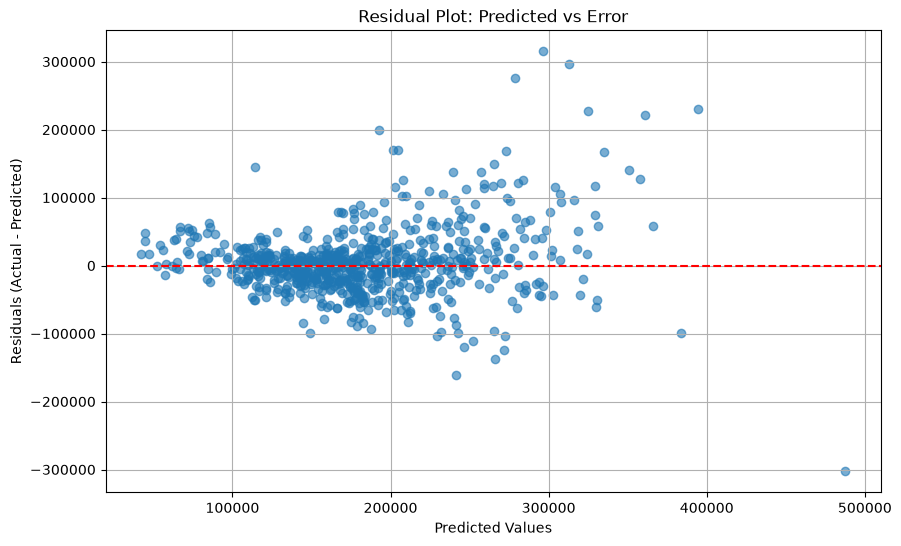

In [14]:
# Generate an error plot to visualise the differences between the predicted 
# and actual values in the test set.

residuals = Y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Predicted vs Error')
plt.grid(True)
plt.show()

In [15]:
# Print the coefficients and interpret them within the context of the median value prediction.

median_living_area = X_train['Gr_Liv_Area'].median()
median_garage = X_train['Garage_Area'].median()

coefficient_liv = multiple_model.coef_[0]
coefficient_garage = multiple_model.coef_[1]
intercept = multiple_model.intercept_

median_prediction = (intercept + (coefficient_liv * median_living_area) 
                     + (coefficient_garage * median_garage))

print(f"Median Living Area: {median_living_area}")
print(f"Median Garage Area: {median_garage}")
print("Living Area Coefficient:", coefficient_liv)
print("Garage Area Coefficient:", coefficient_garage)
print(f"Median Value Prediction: ${median_prediction:,.2f}")

Median Living Area: 1440.0
Median Garage Area: 477.0
Living Area Coefficient: 78.69286848121419
Garage Area Coefficient: 141.14571760877217
Median Value Prediction: $175,584.79


**Interpret coefficients in the context of the prediction:**
Since the coefficients for both living area and garage area are positive, we can see that they both positively impact the value of houses, especially garage area. The value of a house increases by approximately 78.69 dollars for each square foot of living area, and 141.15 dollars for each square foot of garage area. 

**Summarise findings**

The histograms showing distributions for living area, garage area and sale price all have a negative skew, meaning on average homes in Ames tend to be smaller and cheaper. The scatter plot findings are supported by the correlation matrix, in that they show strong positive correlations between living area and sale price (0.71) as well as between garage area and sale price (0.64). 

The linear regression model had a root mean squared error of 51326.13 which means that on average the price predictions are off by 51326.13 dollars. The residual error plot shows that most home prices are accurately predicted, but the more expensive the home becomes the worse the model is at accurately predicting its price and the errors become larger. To reduce errors, more independent variables should be taken into account when predicting prices. 